In [17]:
import numpy as np
from rich import box
from rich.columns import Columns
from rich.console import Console, Group
from rich.panel import Panel
from rich.table import Table

console = Console(width=128)

#### Raman noise estimation

In [41]:
# PARAMS

P_0 = 1e-6          # W, launched pump power
rho_f = 1.6e-9      # km^-1 nm^-1, forward coefficient
rho_b = 1.6e-9      # km^-1 nm^-1, backward coefficient
X = 70e6           # bandwidth of the filter placed on the idler path (Hz)
lambda_T = 1552e-9  # signal wavelength (m)
L = 50              # fiber length (km)
alpha = 0.0461      # km^-1, i.e. ~0.20 dB/km
c = 3e8
h = 6.626e-34
eta = 0.5           # total detection efficiency
B = 20e6             # bandwidth of the detector (Hz)
Gain = 3*1e4 # V/W
P_LO = 100e-6
NEP = 10 * 1e-12 # W/sqrt(Hz)

In [42]:

# Bandwidth conversion: Hz -> nm
Delta_lambda_B_m = lambda_T**2 / c * X
Delta_lambda_B_nm = Delta_lambda_B_m / 1e-9

# Forward Raman power at far end
P_R_f = P_0 * rho_f * Delta_lambda_B_nm * L * np.exp(-alpha * L)

# Backward Raman power at launch end
P_R_b = P_0 * rho_b * Delta_lambda_B_nm * (1 - np.exp(-2 * alpha * L)) / (2 * alpha)

# Pump power at node
P_node = P_0 * np.exp(-alpha * L)

# Pump power after travelling back to middle station
P_f = P_node * np.exp(-alpha * L)

# Photon energy
E_ph = h * c / lambda_T

# Count rates
C_R_f = eta * P_R_f / E_ph
C_R_b = eta * P_R_b / E_ph
C_R_total = C_R_f + C_R_b

# Detector snr estimation
P_beat_rms = np.sqrt(2 * P_LO * P_f)
V_beat_rms = Gain * P_beat_rms
V_noise_rms = Gain * NEP * np.sqrt(B)
SNR = (V_beat_rms / V_noise_rms)**2

params_table = Table(
    title="Simulation parameters",
    title_style="bold red",
    header_style="bold white on red",
    border_style="red",
    box=box.ROUNDED,
    show_lines=True,
)
params_table.add_column("Parameter", style="bold white", no_wrap=True)
params_table.add_column("Value", justify="right", style="bright_red")
params_table.add_column("Unit", style="dim")
params_table.add_row("Launched pump power", f"{P_0 * 1e6:.3f}", "uW")
params_table.add_row("Raman coefficient", f"{rho_f:.2e}", "km^-1 nm^-1")
params_table.add_row("Filter bandwidth", f"{X / 1e6:.0f}", "MHz")
params_table.add_row("Detector bandwidth", f"{B / 1e6:.0f}", "MHz")
params_table.add_row("Signal wavelength", f"{lambda_T * 1e9:.1f}", "nm")
params_table.add_row("Fiber length", f"{L:g}", "km")
params_table.add_row("Loss coefficient", f"{alpha:.4f}", "km^-1")
params_table.add_row("Detection efficiency", f"{eta:.2f}", "")

raman_table = Table(
    title="Raman scattering",
    title_style="bold cyan",
    header_style="bold white on dark_cyan",
    border_style="cyan",
    box=box.ROUNDED,
    show_lines=True,
)
raman_table.add_column("Quantity", style="bold white", no_wrap=True)
raman_table.add_column("Value", justify="right", style="bright_cyan")
raman_table.add_column("Unit", style="dim")
raman_table.add_row("Fwd count rate", f"{C_R_f:.2e}", "Hz")
raman_table.add_row("Bwd count rate", f"{C_R_b:.2e}", "Hz", style="bold black on bright_cyan")
raman_table.add_row("Pump @ node", f"{P_node * 1e9:.1f}", "nW")
raman_table.add_row("Pump back @ middle", f"{P_f * 1e9:.1f}", "nW")

detector_table = Table(
    title="Detector SNR",
    title_style="bold magenta",
    header_style="bold white on dark_magenta",
    border_style="magenta",
    box=box.ROUNDED,
    show_lines=True,
)
detector_table.add_column("Quantity", style="bold white", no_wrap=True)
detector_table.add_column("Value", justify="right", style="bright_magenta")
detector_table.add_column("Unit", style="dim")
detector_table.add_row("Beat voltage (rms)", f"{V_beat_rms * 1e3:.2f}", "mV", style="bold black on bright_magenta")
detector_table.add_row("Beat voltage", f"{10 * np.log10(V_beat_rms**2 / 50 / 1e-3):.1f}", "dBm")
detector_table.add_row("Noise voltage (rms)", f"{V_noise_rms * 1e3:.2f}", "mV")
detector_table.add_row("Noise voltage", f"{10 * np.log10(V_noise_rms**2 / 50 / 1e-3):.1f}", "dBm")
detector_table.add_row("SNR", f"{SNR:.2f}", f"{10 * np.log10(SNR):.1f} dB", style="bold black on bright_green")

console.print(
    Panel(
        Group(
            params_table,
            Columns([raman_table, detector_table], padding=(0, 2), expand=True),
        ),
        title="[bold white]Noise estimation[/]",
        subtitle="[dim]Raman scattering and detector SNR[/]",
        border_style="bright_blue",
        padding=(1, 2),
    )
)

╭────────────────────────────────────────────────────── Noise estimation ──────────────────────────────────────────────────────╮
│                                                                                                                              │
│                Simulation parameters                                                                                         │
│  ╭──────────────────────┬──────────┬─────────────╮                                                                           │
│  │ Parameter            │    Value │ Unit        │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Launched pump power  │    1.000 │ uW          │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Raman coefficient    │ 1.60e-09 │ km^-1 nm^-1 │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Filter bandwidth     │       70 │ MHz         │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Detector bandwidth   │       20 │ MHz         │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Signal wavelength    │   1552.0 │ nm          │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Fiber length         │       50 │ km          │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Loss coefficient     │   0.0461 │ km^-1       │                                                                           │
│  ├──────────────────────┼──────────┼─────────────┤                                                                           │
│  │ Detection efficiency │     0.50 │             │                                                                           │
│  ╰──────────────────────┴──────────┴─────────────╯                                                                           │
│              Raman scattering                                                Detector SNR                                    │
│  ╭────────────────────┬──────────┬──────╮                     ╭─────────────────────┬────────┬─────────╮                     │
│  │ Quantity           │    Value │ Unit │                     │ Quantity            │  Value │ Unit    │                     │
│  ├────────────────────┼──────────┼──────┤                     ├─────────────────────┼────────┼─────────┤                     │
│  │ Fwd count rate     │ 1.75e+01 │ Hz   │                     │ Beat voltage (rms)  │  42.32 │ mV      │                     │
│  ├────────────────────┼──────────┼──────┤                     ├─────────────────────┼────────┼─────────┤                     │
│  │ Bwd count rate     │ 3.77e+01 │ Hz   │                     │ Beat voltage        │  -14.5 │ dBm     │                     │
│  ├────────────────────┼──────────┼──────┤                     ├─────────────────────┼────────┼─────────┤                     │
│  │ Pump @ node        │     99.8 │ nW   │                     │ Noise voltage (rms) │   1.34 │ mV      │                     │
│

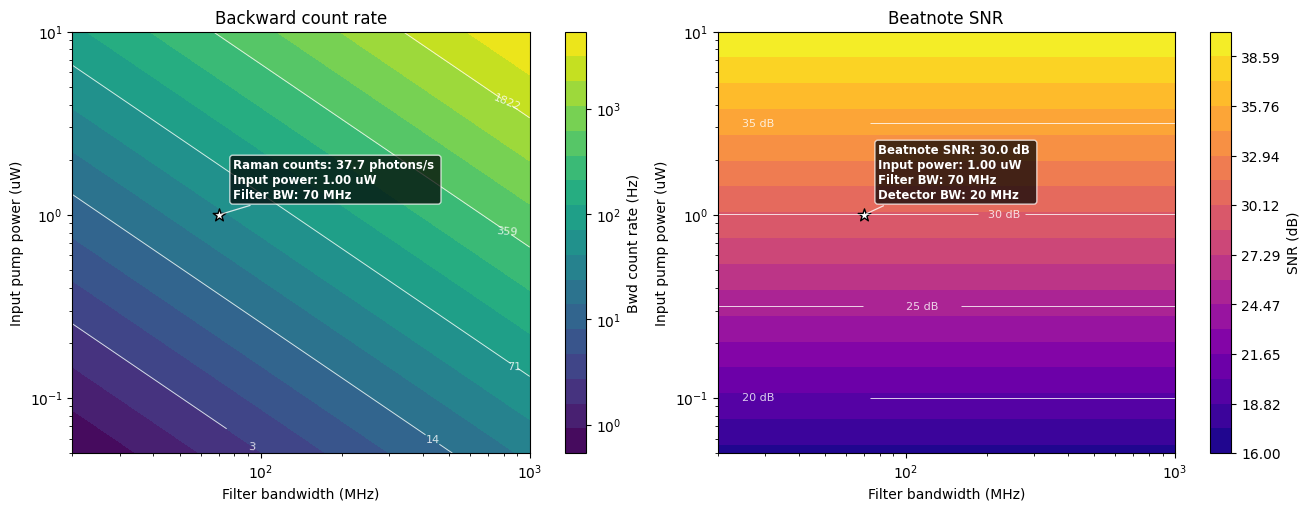

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterSciNotation, LogLocator

filter_bandwidth_MHz = np.geomspace(20, 1000, 180)
pump_power_uW = np.geomspace(0.05, 10, 180)
X_grid_MHz, P0_grid_uW = np.meshgrid(filter_bandwidth_MHz, pump_power_uW)
X_grid = X_grid_MHz * 1e6
P0_grid = P0_grid_uW * 1e-6

delta_lambda_grid_nm = (lambda_T**2 / c * X_grid) / 1e-9
P_R_b_grid = P0_grid * rho_b * delta_lambda_grid_nm * (1 - np.exp(-2 * alpha * L)) / (2 * alpha)
C_R_b_grid = eta * P_R_b_grid / E_ph

# For the SNR sweep, keep the detector noise bandwidth fixed at B.
P_f_grid = P0_grid * np.exp(-2 * alpha * L)
V_beat_grid = Gain * np.sqrt(2 * P_LO * P_f_grid)
V_noise_grid = Gain * NEP * np.sqrt(B)
SNR_grid = (V_beat_grid / V_noise_grid) ** 2
SNR_dB_grid = 10 * np.log10(SNR_grid)
current_bwd_count_rate = C_R_b
current_snr_db = 10 * np.log10(SNR)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

bwd_norm = LogNorm(vmin=C_R_b_grid.min(), vmax=C_R_b_grid.max())
bwd_levels = np.geomspace(C_R_b_grid.min(), C_R_b_grid.max(), 18)
bwd_filled = axes[0].contourf(
    X_grid_MHz,
    P0_grid_uW,
    C_R_b_grid,
    levels=bwd_levels,
    norm=bwd_norm,
    cmap="viridis",
)
bwd_lines = axes[0].contour(
    X_grid_MHz,
    P0_grid_uW,
    C_R_b_grid,
    levels=bwd_levels[::3],
    colors="white",
    linewidths=0.7,
    alpha=0.8,
)
axes[0].clabel(bwd_lines, fmt="%.0f", fontsize=8)
bwd_colorbar = fig.colorbar(bwd_filled, ax=axes[0], label="Bwd count rate (Hz)")
bwd_colorbar.locator = LogLocator(base=10)
bwd_colorbar.formatter = LogFormatterSciNotation(base=10)
bwd_colorbar.update_ticks()
axes[0].set_title("Backward count rate")

snr_levels = np.linspace(np.floor(SNR_dB_grid.min()), np.ceil(SNR_dB_grid.max()), 18)
snr_filled = axes[1].contourf(
    X_grid_MHz,
    P0_grid_uW,
    SNR_dB_grid,
    levels=snr_levels,
    cmap="plasma",
)
snr_lines = axes[1].contour(
    X_grid_MHz,
    P0_grid_uW,
    SNR_dB_grid,
    levels=np.arange(np.floor(SNR_dB_grid.min() / 5) * 5, np.ceil(SNR_dB_grid.max() / 5) * 5 + 1, 5),
    colors="white",
    linewidths=0.7,
    alpha=0.8,
)
axes[1].clabel(snr_lines, fmt="%.0f dB", fontsize=8)
fig.colorbar(snr_filled, ax=axes[1], label="SNR (dB)")
axes[1].set_title("Beatnote SNR")

current_point_labels = [
    (axes[0], f"Raman counts: {current_bwd_count_rate:.1f} photons/s \nInput power: {P_0 * 1e6:.2f} uW \nFilter BW: {X / 1e6:.0f} MHz"),
    (axes[1], f"Beatnote SNR: {current_snr_db:.1f} dB \nInput power: {P_0 * 1e6:.2f} uW \nFilter BW: {X / 1e6:.0f} MHz \nDetector BW: {B / 1e6:.0f} MHz"),
]

for ax, current_label in current_point_labels:
    ax.scatter(X / 1e6, P_0 * 1e6, s=90, c="white", edgecolors="black", marker="*", linewidths=1.0, label="Current point")
    ax.annotate(
        current_label,
        xy=(X / 1e6, P_0 * 1e6),
        xytext=(10, 12),
        textcoords="offset points",
        color="white",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="black", edgecolor="white", alpha=0.72),
        arrowprops=dict(arrowstyle="-", color="white", linewidth=0.9, alpha=0.8),
        zorder=7,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Filter bandwidth (MHz)")
    ax.set_ylabel("Input pump power (uW)")
    ax.grid(False)#, which="both", color="white", linewidth=0.5, alpha=0.35)

plt.show()

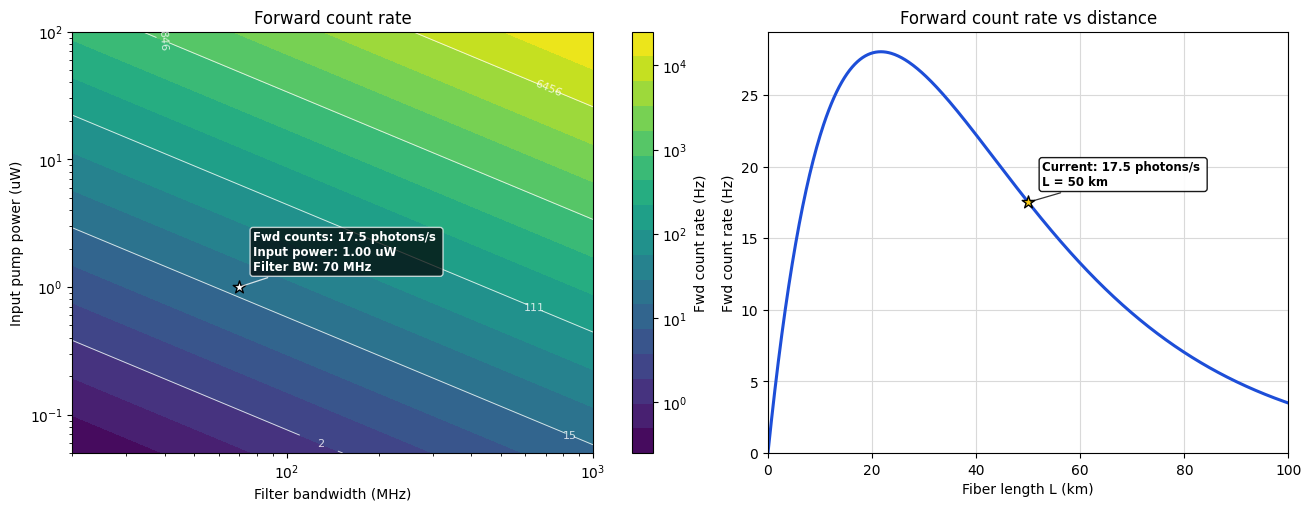

In [44]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterSciNotation, LogLocator

filter_bandwidth_MHz = np.geomspace(20, 1000, 180)
pump_power_uW = np.geomspace(0.05, 100, 180)
X_grid_MHz, P0_grid_uW = np.meshgrid(filter_bandwidth_MHz, pump_power_uW)
X_grid = X_grid_MHz * 1e6
P0_grid = P0_grid_uW * 1e-6

delta_lambda_grid_nm = (lambda_T**2 / c * X_grid) / 1e-9
P_R_f_grid = P0_grid * rho_f * delta_lambda_grid_nm * L * np.exp(-alpha * L)
C_R_f_grid = eta * P_R_f_grid / E_ph

L_scan = np.linspace(0, max(100, 1.25 * L), 600)
P_R_f_vs_L = P_0 * rho_f * Delta_lambda_B_nm * L_scan * np.exp(-alpha * L_scan)
C_R_f_vs_L = eta * P_R_f_vs_L / E_ph

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

fwd_norm = LogNorm(vmin=C_R_f_grid.min(), vmax=C_R_f_grid.max())
fwd_levels = np.geomspace(C_R_f_grid.min(), C_R_f_grid.max(), 18)
fwd_filled = axes[0].contourf(
    X_grid_MHz,
    P0_grid_uW,
    C_R_f_grid,
    levels=fwd_levels,
    norm=fwd_norm,
    cmap="viridis",
)
fwd_lines = axes[0].contour(
    X_grid_MHz,
    P0_grid_uW,
    C_R_f_grid,
    levels=fwd_levels[::3],
    colors="white",
    linewidths=0.7,
    alpha=0.8,
)
axes[0].clabel(fwd_lines, fmt="%.0f", fontsize=8)
fwd_colorbar = fig.colorbar(fwd_filled, ax=axes[0], label="Fwd count rate (Hz)")
fwd_colorbar.locator = LogLocator(base=10)
fwd_colorbar.formatter = LogFormatterSciNotation(base=10)
fwd_colorbar.update_ticks()
axes[0].scatter(X / 1e6, P_0 * 1e6, s=90, c="white", edgecolors="black", marker="*", linewidths=1.0, zorder=7)
axes[0].annotate(
    f"Fwd counts: {C_R_f:.1f} photons/s \nInput power: {P_0 * 1e6:.2f} uW \nFilter BW: {X / 1e6:.0f} MHz",
    xy=(X / 1e6, P_0 * 1e6),
    xytext=(10, 12),
    textcoords="offset points",
    color="white",
    fontsize=8.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="black", edgecolor="white", alpha=0.72),
    arrowprops=dict(arrowstyle="-", color="white", linewidth=0.9, alpha=0.8),
    zorder=7,
)
axes[0].set_title("Forward count rate")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Filter bandwidth (MHz)")
axes[0].set_ylabel("Input pump power (uW)")
axes[0].grid(False)

axes[1].plot(L_scan, C_R_f_vs_L, color="#1d4ed8", linewidth=2.2)
axes[1].scatter(L, C_R_f, s=90, c="#facc15", edgecolors="black", marker="*", linewidths=1.0, zorder=7)
axes[1].annotate(
    f"Current: {C_R_f:.1f} photons/s \nL = {L:g} km",
    xy=(L, C_R_f),
    xytext=(10, 12),
    textcoords="offset points",
    fontsize=8.5,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.9),
    arrowprops=dict(arrowstyle="-", color="black", linewidth=0.9, alpha=0.8),
    zorder=7,
)
axes[1].set_title("Forward count rate vs distance")
axes[1].set_xlabel("Fiber length L (km)")
axes[1].set_ylabel("Fwd count rate (Hz)")
axes[1].set_xlim(L_scan.min(), L_scan.max())
axes[1].set_ylim(bottom=0)
axes[1].grid(True, color="0.85", linewidth=0.8)

plt.show()

#### Filter design

In [2]:
from dataclasses import dataclass
import numpy as np


@dataclass
class FabryPerotCavity:
    """
    Two-mirror linear Fabry-Perot / monolithic filter cavity.

    Parameters
    ----------
    Rin, Rout : float
        Intensity reflectivities of input and output mirrors.
        Example: 98.8% -> 0.988

    length_mm : float
        Physical substrate/cavity thickness in mm.

    n : float
        Refractive index of the substrate.

    alpha_cm : float
        Bulk intensity loss coefficient in cm^-1.
        This models absorption/scattering in the substrate.

    mode_matching : float
        Fraction of incident power coupled to the cavity TEM00 mode.
        1.0 means perfect mode matching.

    extra_delta_rt : float
        Additional round-trip intensity loss in delta notation.
        For small losses, extra_delta_rt = 0.001 corresponds to ~0.1% loss.

    Notes
    -----
    The round-trip intensity survival is

        g_rt = Rin * Rout * exp(-2 alpha L - extra_delta_rt)

    where L is the physical length in cm.
    """

    Rin: float
    Rout: float
    length_mm: float
    n: float
    alpha_cm: float = 5e-4
    mode_matching: float = 1.0
    extra_delta_rt: float = 0.0
    c: float = 299_792_458.0

    def __post_init__(self):
        for name in ("Rin", "Rout"):
            R = getattr(self, name)
            if not (0.0 < R < 1.0):
                raise ValueError(f"{name} must be between 0 and 1.")

        if self.length_mm <= 0:
            raise ValueError("length_mm must be positive.")

        if self.n <= 0:
            raise ValueError("n must be positive.")

        if self.alpha_cm < 0:
            raise ValueError("alpha_cm must be non-negative.")

        if not (0.0 <= self.mode_matching <= 1.0):
            raise ValueError("mode_matching must be between 0 and 1.")

    @property
    def length_m(self):
        return self.length_mm * 1e-3

    @property
    def length_cm(self):
        return self.length_mm / 10.0

    @property
    def leff_m(self):
        """
        Round-trip optical path length.
        For a linear cavity fully filled with index n:

            l_eff = 2 n L
        """
        return 2.0 * self.n * self.length_m

    @property
    def fsr_hz(self):
        """
        Free spectral range.
        """
        return self.c / self.leff_m

    @property
    def internal_oneway_survival(self):
        """
        One-way internal intensity survival excluding mirror transmission/reflection.
        """
        return np.exp(-self.alpha_cm * self.length_cm - 0.5 * self.extra_delta_rt)

    @property
    def internal_roundtrip_survival(self):
        """
        Round-trip internal intensity survival excluding mirror reflectivities.
        """
        return np.exp(-2.0 * self.alpha_cm * self.length_cm - self.extra_delta_rt)

    @property
    def grt(self):
        """
        Net round-trip intensity survival including both mirror reflectivities.
        """
        return self.Rin * self.Rout * self.internal_roundtrip_survival

    @property
    def sqrt_grt(self):
        """
        Net round-trip amplitude survival.
        """
        return np.sqrt(self.grt)

    def phase_factors(self, detuning_hz=0.0):
        """
        Phase factors for a frequency detuning from cavity resonance.

        detuning_hz = 0 gives g = 1, i.e. exact resonance.
        """
        phi_rt = 2.0 * np.pi * detuning_hz / self.fsr_hz
        g_rt_phase = np.exp(-1j * phi_rt)
        g_oneway_phase = np.exp(-0.5j * phi_rt)
        return g_rt_phase, g_oneway_phase

    def fields(self, detuning_hz=0.0, Einc=1.0):
        """
        Return complex field amplitudes relative to incident field.

        Returns
        -------
        dict with:
            Ecirc  : intracavity field just after the input mirror
            Etrans : transmitted field
            Erefl  : reflected field
        """
        g, g0 = self.phase_factors(detuning_hz)
        denom = 1.0 - self.sqrt_grt * g

        Ecirc = (
            1j
            * Einc
            * np.sqrt(1.0 - self.Rin)
            / denom
        )

        Etrans = (
            1j
            * np.sqrt(1.0 - self.Rout)
            * np.sqrt(self.internal_oneway_survival)
            * g0
            * Ecirc
        )

        Erefl = (
            Einc
            * (self.Rin - self.sqrt_grt * g)
            / (np.sqrt(self.Rin) * denom)
        )

        return {
            "Ecirc": Ecirc,
            "Etrans": Etrans,
            "Erefl": Erefl,
        }

    def powers(self, detuning_hz=0.0):
        """
        Return power ratios relative to incident power.

        T_cavity and R_cavity are for the mode-matched part only.
        T and R include the simple mode-matching correction:

            T_measured = eta T_cavity
            R_measured = (1 - eta) + eta R_cavity

        where eta = mode_matching.
        """
        f = self.fields(detuning_hz=detuning_hz, Einc=1.0)

        T_cavity = np.abs(f["Etrans"]) ** 2
        R_cavity = np.abs(f["Erefl"]) ** 2
        P_circ = np.abs(f["Ecirc"]) ** 2

        eta = self.mode_matching

        T = eta * T_cavity
        R = (1.0 - eta) + eta * R_cavity
        A = 1.0 - T - R

        return {
            "T_cavity": T_cavity,
            "R_cavity": R_cavity,
            "T": T,
            "R": R,
            "A": A,
            "P_circ": P_circ,
        }

    def linewidth_fwhm_hz(self):
        """
        Exact Airy FWHM linewidth in Hz.

        Uses the round-trip amplitude survival a = sqrt(g_rt).
        """
        a = self.sqrt_grt

        # Half-maximum condition:
        # 1 + a^2 - 2 a cos(phi_half) = 2 (1 - a)^2
        cos_phi_half = (4.0 * a - 1.0 - a**2) / (2.0 * a)
        cos_phi_half = np.clip(cos_phi_half, -1.0, 1.0)

        phi_half = np.arccos(cos_phi_half)

        return self.fsr_hz * phi_half / np.pi

    def finesse(self):
        return self.fsr_hz / self.linewidth_fwhm_hz()

    def suppression_db(self, detuning_hz):
        """
        Transmission suppression at detuning_hz relative to on-resonance transmission.

        Returns negative dB values:

            10 log10(T(detuning) / T(0))
        """
        T0 = self.powers(detuning_hz=0.0)["T"]
        Tdet = self.powers(detuning_hz=detuning_hz)["T"]
        return 10.0 * np.log10(Tdet / T0)

    def critical_coupling_Rin(self):
        """
        Input mirror reflectivity required for zero reflected field on resonance.

        From Erefl = 0:

            Rin = Rout * internal_roundtrip_survival
        """
        return self.Rout * self.internal_roundtrip_survival

    def impedance_mismatch(self):
        """
        Difference between actual Rin and critical-coupling Rin.

        Positive value means the input mirror is too reflective.
        Negative value means the input mirror is too transmissive.
        """
        return self.Rin - self.critical_coupling_Rin()

    def summary(self):
        p0 = self.powers(detuning_hz=0.0)

        return {
            "FSR_Hz": self.fsr_hz,
            "FSR_GHz": self.fsr_hz / 1e9,
            "FWHM_Hz": self.linewidth_fwhm_hz(),
            "FWHM_MHz": self.linewidth_fwhm_hz() / 1e6,
            "finesse": self.finesse(),
            "T_on_resonance": p0["T"],
            "R_on_resonance": p0["R"],
            "A_on_resonance": p0["A"],
            "circulating_power_enhancement": p0["P_circ"],
            "internal_roundtrip_survival": self.internal_roundtrip_survival,
            "grt": self.grt,
            "critical_coupling_Rin": self.critical_coupling_Rin(),
            "impedance_mismatch": self.impedance_mismatch(),
        }

In [3]:
cav = FabryPerotCavity(
    Rin=0.988,
    Rout=0.988,
    length_mm=6.35,
    n=1.46,
    alpha_cm=5e-4,
    mode_matching=1.0,
)
abc = cav.summary()
print(abc)

print("Suppression at 6.8 GHz:", cav.suppression_db(6.8e9), "dB")

{'FSR_Hz': 16168291338.582678, 'FSR_GHz': 16.168291338582677, 'FWHM_Hz': np.float64(63766703.06677788), 'FWHM_MHz': np.float64(63.76670306677788), 'finesse': np.float64(253.55382293562977), 'T_on_resonance': np.float64(0.9494053705177794), 'R_on_resonance': np.float64(0.0006566494721147917), 'A_on_resonance': np.float64(0.049937980010105805), 'circulating_power_enhancement': np.float64(79.14223788174837), 'internal_roundtrip_survival': np.float64(0.9993652015698321), 'grt': np.float64(0.9755243453211822), 'critical_coupling_Rin': np.float64(0.9873728191509941), 'impedance_mismatch': np.float64(0.0006271808490059261)}
Suppression at 6.8 GHz: -43.885999533883016 dB


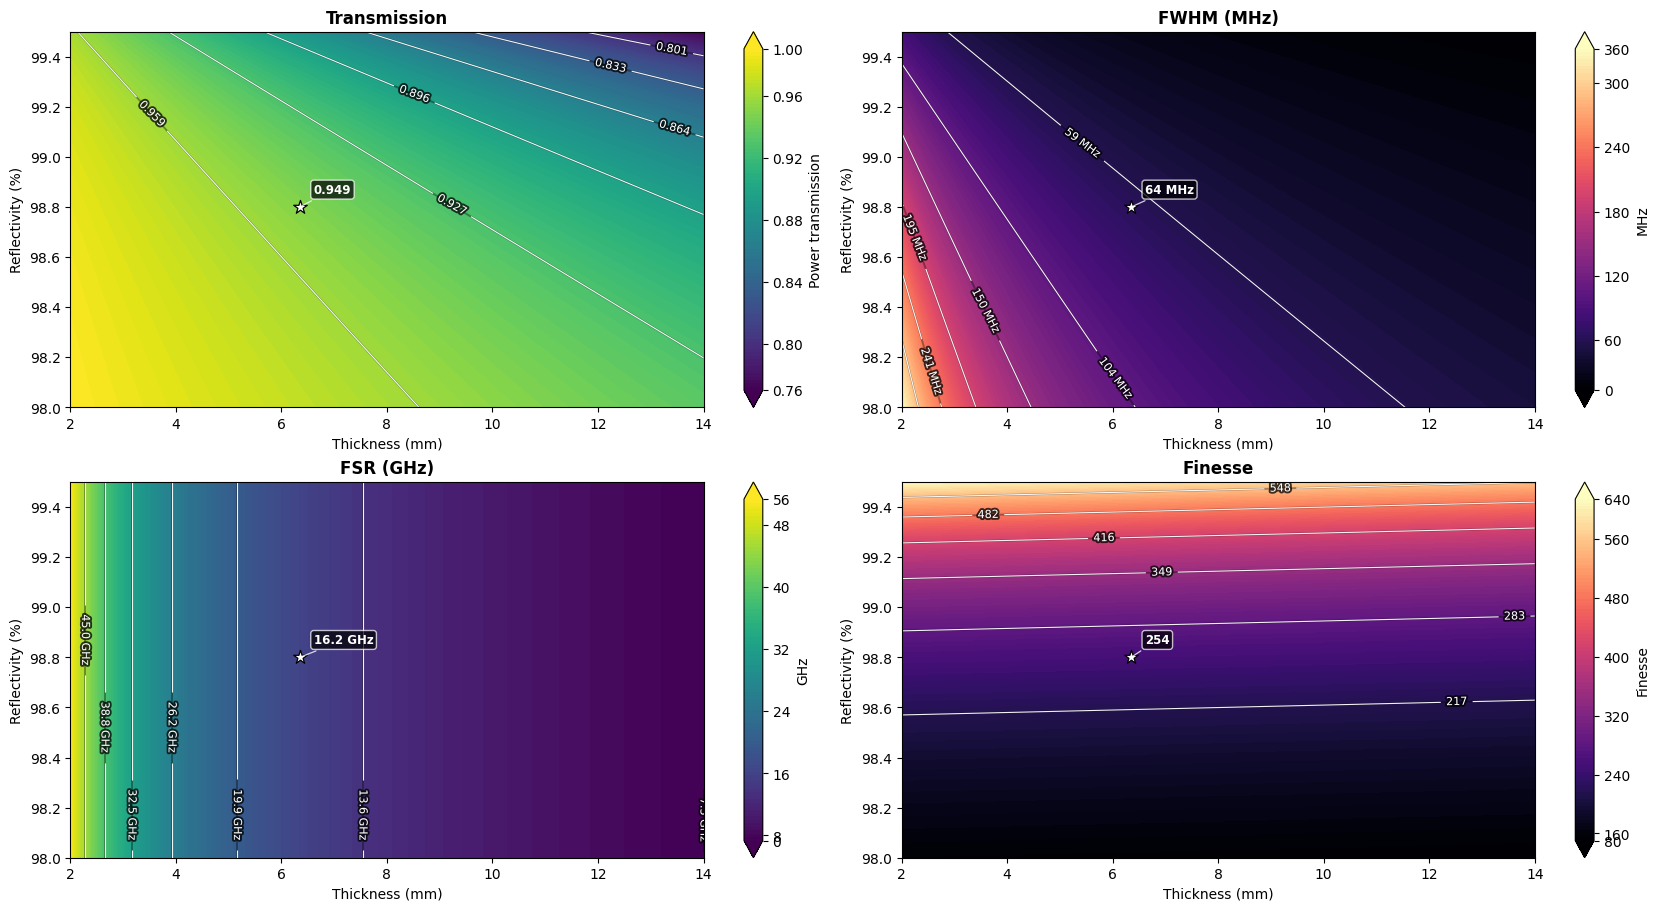

╭─────────────────────────────────────────── Cavity design summary ────────────────────────────────────────────╮
│                                                                                                              │
│                     Chosen design point                                                                      │
│  ╭───────────┬───────────────────────┬───────────┬───────╮                                                   │
│  │ Group     │ Quantity              │     Value │ Unit  │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Geometry  │ Mirror reflectivity   │    98.800 │ %     │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Geometry  │ Cavity thickness      │     6.350 │ mm    │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Geometry  │ Mirror ROC            │      7.50 │ cm    │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Material  │ Refractive index      │    1.4600 │       │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Material  │ Bulk loss coefficient │ 5.000e-04 │ cm^-1 │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Material  │ Extra round-trip loss │ 0.000e+00 │       │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Optical   │ FSR                   │    16.168 │ GHz   │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Optical   │ FWHM                  │    63.767 │ MHz   │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Optical   │ Finesse               │    253.55 │       │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Power     │ Transmission          │     94.94 │ %     │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Power     │ Reflection            │    0.0657 │ %     │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Power     │ Absorption/loss       │      4.99 │ %     │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Filtering │ Suppression @ 6.8 GHz │    -29.88 │ dB    │                                                   │
│  ├───────────┼───────────────────────┼───────────┼───────┤                                                   │
│  │ Mode      │ Rayleigh length       │     2.469 │ cm    │                                                   │
│  ╰───────────┴───────────────────────┴───────────┴───────╯                                                   │
│                                                                                                              │
╰──────────────────────────────────── R=98.80

In [4]:
# Design parameters
R_choice = 0.988
L_choice_mm = 6.35
alpha_cm = 5e-4
n = 1.46

# Frequency where suppression is evaluated
detuning_hz = 1e9

# Mirror ROC used for the mode waist calculation.
# The paper comparison matches the optical-length convention L_eff = n L.
roc_cm = 7.5

# Extra round-trip loss.
extra_delta_rt = 0.0
# extra_delta_rt = 2.05e-4

# scan ranges
R_values = np.linspace(0.980, 0.995, 220)
L_values_mm = np.linspace(2.0, 14.0, 220)

R_values_percent = 100.0 * R_values
L_grid_mm, R_grid_percent = np.meshgrid(L_values_mm, R_values_percent)


# ------------------------------------------------------------
# Storage arrays
# Shape: rows = reflectivity, columns = thickness
# ------------------------------------------------------------

T = np.empty((len(R_values), len(L_values_mm)))
suppression_db = np.empty_like(T)
fwhm_MHz = np.empty_like(T)
fsr_GHz = np.empty_like(T)
finesse_grid = np.empty_like(T)


def rayleigh_length_plano_concave_cm(length_mm, roc_cm, n_medium=1.0):
    """
    Rayleigh length for a plano-concave cavity.

    The comparison paper's plotted values match the convention:

        L_eff = n * L_physical
        z_R = sqrt(L_eff * (ROC - L_eff))

    with L_eff and ROC in cm.
    """
    L_eff_cm = n_medium * length_mm / 10.0
    return np.sqrt(np.maximum(L_eff_cm * (roc_cm - L_eff_cm), 0.0))


# ------------------------------------------------------------
# Main loop over cavity parameters
# ------------------------------------------------------------

for i, R in enumerate(R_values):
    for j, L_mm in enumerate(L_values_mm):

        cav = FabryPerotCavity(
            Rin=R,
            Rout=R,
            length_mm=L_mm,
            n=n,
            alpha_cm=alpha_cm,
            mode_matching=1.0,
            extra_delta_rt=extra_delta_rt,
        )

        T[i, j] = cav.powers(detuning_hz=0.0)["T"]
        suppression_db[i, j] = cav.suppression_db(detuning_hz)
        fwhm_MHz[i, j] = cav.linewidth_fwhm_hz() / 1e6
        fsr_GHz[i, j] = cav.fsr_hz / 1e9
        finesse_grid[i, j] = cav.finesse()


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.ticker import MaxNLocator
from rich import box
from rich.console import Console
from rich.panel import Panel
from rich.table import Table


def labeled_contours(ax, x, y, z, levels, fmt):
    shadow = ax.contour(
        x,
        y,
        z,
        levels=levels,
        colors="black",
        linewidths=1.4,
        alpha=0.35,
    )
    lines = ax.contour(
        x,
        y,
        z,
        levels=levels,
        colors="white",
        linewidths=0.8,
        alpha=0.95,
    )
    labels = ax.clabel(lines, fmt=fmt, fontsize=8, inline=True, inline_spacing=4)
    for label in labels:
        label.set_color("white")
        label.set_path_effects([
            path_effects.withStroke(linewidth=2.8, foreground="black", alpha=0.75)
        ])
    return shadow, lines


fig, axs = plt.subplots(2, 2, figsize=(16.5, 9), constrained_layout=True)
fig.patch.set_facecolor("white")

chosen_plot = FabryPerotCavity(
    Rin=R_choice,
    Rout=R_choice,
    length_mm=L_choice_mm,
    n=n,
    alpha_cm=alpha_cm,
    mode_matching=1.0,
    extra_delta_rt=extra_delta_rt,
)
chosen_plot_p0 = chosen_plot.powers(detuning_hz=0.0)

panels = [
    {
        "ax": axs[0, 0],
        "Z": T,
        "title": "Transmission",
        "cbar": "Power transmission",
        "cmap": "viridis",
        "filled_levels": np.linspace(np.nanmin(T), np.nanmax(T), 100),
        "line_levels": np.linspace(np.nanmin(T), np.nanmax(T), 8),
        "fmt": lambda value: f"{value:.3f}",
        "chosen_value": chosen_plot_p0["T"],
    },
    #{
    #    "ax": axs[0, 1],
    #    "Z": suppression_db,
    #    "title": "Suppression @ 1 GHz from resonance",
    #    "cbar": "dB",
    #    "cmap": "magma",
    #    "filled_levels": np.linspace(np.nanmin(suppression_db), np.nanmax(suppression_db), 100),
    #    "line_levels": np.linspace(np.nanmin(suppression_db), np.nanmax(suppression_db), 8),
    #    "fmt": lambda value: f"{value:.0f} dB",
    #    "chosen_value": chosen_plot.suppression_db(detuning_hz),
    #},
    {
        "ax": axs[0, 1],
        "Z": fwhm_MHz,
        "title": "FWHM (MHz)",
        "cbar": "MHz",
        "cmap": "magma",
        "filled_levels": np.linspace(np.nanmin(fwhm_MHz), np.nanmax(fwhm_MHz), 100),
        "line_levels": np.linspace(np.nanmin(fwhm_MHz), np.nanmax(fwhm_MHz), 8),
        "fmt": lambda value: f"{value:.0f} MHz",
        "chosen_value": chosen_plot.linewidth_fwhm_hz() / 1e6,
    },
    {
        "ax": axs[1, 0],
        "Z": fsr_GHz,
        "title": "FSR (GHz)",
        "cbar": "GHz",
        "cmap": "viridis",
        "filled_levels": np.linspace(np.nanmin(fsr_GHz), np.nanmax(fsr_GHz), 100),
        "line_levels": np.linspace(np.nanmin(fsr_GHz), np.nanmax(fsr_GHz), 8),
        "fmt": lambda value: f"{value:.1f} GHz",
        "chosen_value": chosen_plot.fsr_hz / 1e9,
    },
    {
        "ax": axs[1, 1],
        "Z": finesse_grid,
        "title": "Finesse",
        "cbar": "Finesse",
        "cmap": "magma",
        "filled_levels": np.linspace(np.nanmin(finesse_grid), np.nanmax(finesse_grid), 100),
        "line_levels": np.linspace(np.nanmin(finesse_grid), np.nanmax(finesse_grid), 8),
        "fmt": lambda value: f"{value:.0f}",
        "chosen_value": chosen_plot.finesse(),
    },
]
#axs[1, 2].set_visible(False)

for p in panels:
    ax = p["ax"]
    Z = p["Z"]

    cf = ax.contourf(
        L_grid_mm,
        R_grid_percent,
        Z,
        levels=p["filled_levels"],
        cmap=p["cmap"],
        extend="both",
    )

    labeled_contours(ax, L_grid_mm, R_grid_percent, Z, p["line_levels"], p["fmt"])

    ax.scatter(
        L_choice_mm,
        100.0 * R_choice,
        s=105,
        marker="*",
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
        label="Chosen design",
    )
    ax.annotate(
        p["fmt"](p["chosen_value"]),
        xy=(L_choice_mm, 100.0 * R_choice),
        xytext=(10, 10),
        textcoords="offset points",
        color="white",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="black", edgecolor="white", alpha=0.72),
        arrowprops=dict(arrowstyle="-", color="white", linewidth=0.9, alpha=0.8),
        zorder=7,
    )

    ax.set_title(p["title"], fontweight="bold")
    ax.set_xlabel("Thickness (mm)")
    ax.set_ylabel("Reflectivity (%)")
    ax.grid(False)#, color="white", linewidth=0.45, alpha=0.28)
    ax.set_axisbelow(False)

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(p["cbar"])
    cbar.locator = MaxNLocator(nbins=6)
    cbar.update_ticks()

plt.show()


# ------------------------------------------------------------
# Print chosen design point
# ------------------------------------------------------------

chosen = chosen_plot
p0 = chosen_plot_p0

design_table = Table(
    title="Chosen design point",
    title_style="bold cyan",
    header_style="bold white on dark_cyan",
    border_style="cyan",
    box=box.ROUNDED,
    show_lines=True,
)
design_table.add_column("Group", style="bold white", no_wrap=True)
design_table.add_column("Quantity", style="bold white", no_wrap=True)
design_table.add_column("Value", justify="right", style="bright_cyan")
design_table.add_column("Unit", style="dim")

design_table.add_row("Geometry", "Mirror reflectivity", f"{100 * R_choice:.3f}", "%")
design_table.add_row("Geometry", "Cavity thickness", f"{L_choice_mm:.3f}", "mm")
design_table.add_row("Geometry", "Mirror ROC", f"{roc_cm:.2f}", "cm")
design_table.add_row("Material", "Refractive index", f"{n:.4f}", "")
design_table.add_row("Material", "Bulk loss coefficient", f"{alpha_cm:.3e}", "cm^-1")
design_table.add_row("Material", "Extra round-trip loss", f"{extra_delta_rt:.3e}", "")
design_table.add_row("Optical", "FSR", f"{chosen.fsr_hz / 1e9:.3f}", "GHz")
design_table.add_row("Optical", "FWHM", f"{chosen.linewidth_fwhm_hz() / 1e6:.3f}", "MHz")
design_table.add_row("Optical", "Finesse", f"{chosen.finesse():.2f}", "")
design_table.add_row("Power", "Transmission", f"{100 * p0['T']:.2f}", "%", style="bold black on bright_green")
design_table.add_row("Power", "Reflection", f"{100 * p0['R']:.4f}", "%")
design_table.add_row("Power", "Absorption/loss", f"{100 * p0['A']:.2f}", "%")
design_table.add_row("Filtering", "Suppression @ 6.8 GHz", f"{chosen.suppression_db(detuning_hz):.2f}", "dB", style="bold black on bright_magenta")
design_table.add_row("Mode", "Rayleigh length", f"{rayleigh_length_plano_concave_cm(L_choice_mm, roc_cm, n):.3f}", "cm", style="bold black on bright_cyan")

Console(width=112).print(
    Panel(
        design_table,
        title="[bold white]Cavity design summary[/]",
        subtitle=f"[dim]R={100 * R_choice:.3f}% | L={L_choice_mm:.3f} mm | ROC={roc_cm:.2f} cm[/]",
        border_style="bright_blue",
        padding=(1, 2),
    )
)

╭─────────────────────────────────────── Cavity focal point and waist ───────────────────────────────────────╮
│                                                                                                            │
│                        Mode waist placement                                                                │
│  ╭─────────────────────────────────┬───────┬─────────────────────╮                                         │
│  │ Quantity                        │ Value │ Unit                │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Focal point / waist position    │ 0.000 │ mm from flat mirror │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Mode-matching waist in air      │  75.6 │ um                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Internal waist radius w0        │  75.6 │ um                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Waist diameter 2w0              │ 151.3 │ um                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Beam radius at curved mirror    │  80.8 │ um                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Rayleigh length inside medium   │ 1.691 │ cm                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Rayleigh length in air          │ 1.158 │ cm                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Effective Rayleigh length n z_R │ 2.469 │ cm                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Cavity thickness                │ 6.350 │ mm                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Mirror ROC                      │  7.50 │ cm                  │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Inside half-angle divergence    │ 4.474 │ mrad                │                                         │
│  ├─────────────────────────────────┼───────┼─────────────────────┤                                         │
│  │ Air half-angle divergence       │ 6.531 │ mrad                │                                         │
│  ╰─────────────────────────────────┴───────┴─────────────────────╯                                         │
│                                                                                                            │
╰───────────────── Waist at flat mirror; air-side waist radius equals internal waist radius ─────────────────╯

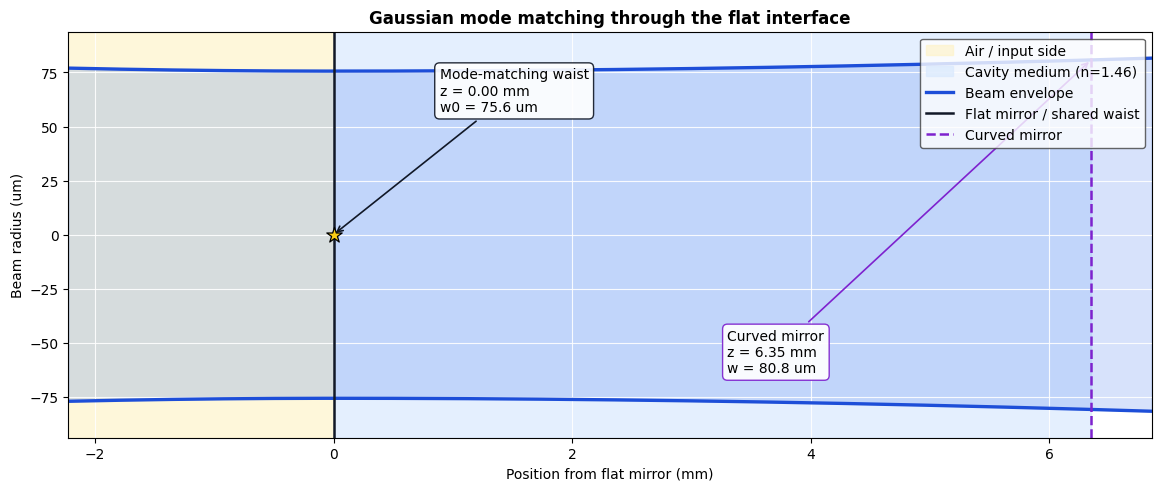

In [5]:
import matplotlib.pyplot as plt
from rich import box
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Plano-concave cavity mode: waist/focal point at the flat mirror.
# The scan uses an optical-length Rayleigh range z_R,eff = n * z_R,in.
# For mode matching from air, use the physical Rayleigh ranges on each side
# of the flat interface while keeping the waist radius continuous.
lambda0_m = globals().get("lambda_T", 1552e-9)
waist_position_mm = 0.0
z_R_eff_cm = rayleigh_length_plano_concave_cm(L_choice_mm, roc_cm, n)
z_R_inside_cm = z_R_eff_cm / n
z_R_air_cm = z_R_inside_cm / n
z_R_inside_m = z_R_inside_cm * 1e-2
z_R_air_m = z_R_air_cm * 1e-2
L_choice_m = L_choice_mm * 1e-3

w0_m = np.sqrt(lambda0_m * z_R_inside_m / (np.pi * n))
w_curved_m = w0_m * np.sqrt(1 + (L_choice_m / z_R_inside_m) ** 2)
divergence_inside_mrad = lambda0_m / (np.pi * n * w0_m) * 1e3
divergence_air_mrad = lambda0_m / (np.pi * w0_m) * 1e3

mode_table = Table(
    title="Mode waist placement",
    title_style="bold cyan",
    header_style="bold white on dark_cyan",
    border_style="cyan",
    box=box.ROUNDED,
    show_lines=True,
)
mode_table.add_column("Quantity", style="bold white", no_wrap=True)
mode_table.add_column("Value", justify="right", style="bright_cyan")
mode_table.add_column("Unit", style="dim")
mode_table.add_row("Focal point / waist position", f"{waist_position_mm:.3f}", "mm from flat mirror", style="bold black on bright_cyan")
mode_table.add_row("Mode-matching waist in air", f"{w0_m * 1e6:.1f}", "um", style="bold black on bright_green")
mode_table.add_row("Internal waist radius w0", f"{w0_m * 1e6:.1f}", "um")
mode_table.add_row("Waist diameter 2w0", f"{2 * w0_m * 1e6:.1f}", "um")
mode_table.add_row("Beam radius at curved mirror", f"{w_curved_m * 1e6:.1f}", "um")
mode_table.add_row("Rayleigh length inside medium", f"{z_R_inside_cm:.3f}", "cm")
mode_table.add_row("Rayleigh length in air", f"{z_R_air_cm:.3f}", "cm")
mode_table.add_row("Effective Rayleigh length n z_R", f"{z_R_eff_cm:.3f}", "cm")
mode_table.add_row("Cavity thickness", f"{L_choice_mm:.3f}", "mm")
mode_table.add_row("Mirror ROC", f"{roc_cm:.2f}", "cm")
mode_table.add_row("Inside half-angle divergence", f"{divergence_inside_mrad:.3f}", "mrad")
mode_table.add_row("Air half-angle divergence", f"{divergence_air_mrad:.3f}", "mrad")

Console(width=110).print(
    Panel(
        mode_table,
        title="[bold white]Cavity focal point and waist[/]",
        subtitle="[dim]Waist at flat mirror; air-side waist radius equals internal waist radius[/]",
        border_style="bright_blue",
        padding=(1, 2),
    )
)

z_mm = np.linspace(-0.35 * L_choice_mm, 1.08 * L_choice_mm, 700)
z_from_waist_m = (z_mm - waist_position_mm) * 1e-3
inside = z_mm >= waist_position_mm
w_um = np.empty_like(z_mm)
w_um[~inside] = w0_m * np.sqrt(1 + (z_from_waist_m[~inside] / z_R_air_m) ** 2) * 1e6
w_um[inside] = w0_m * np.sqrt(1 + (z_from_waist_m[inside] / z_R_inside_m) ** 2) * 1e6
w0_um = w0_m * 1e6
w_curved_um = w_curved_m * 1e6

fig, ax = plt.subplots(figsize=(11.5, 4.8), constrained_layout=True)
fig.patch.set_facecolor("white")

ax.axvspan(z_mm.min(), 0, color="#fef3c7", alpha=0.65, label="Air / input side")
ax.axvspan(0, L_choice_mm, color="#dbeafe", alpha=0.75, label=f"Cavity medium (n={n:.2f})")
ax.fill_between(z_mm, -w_um, w_um, color="#2563eb", alpha=0.18)
ax.plot(z_mm, w_um, color="#1d4ed8", linewidth=2.4, label="Beam envelope")
ax.plot(z_mm, -w_um, color="#1d4ed8", linewidth=2.4)

ax.axvline(0, color="#111827", linewidth=1.8, label="Flat mirror / shared waist")
ax.axvline(L_choice_mm, color="#7e22ce", linestyle="--", linewidth=1.8, label="Curved mirror")
ax.scatter([waist_position_mm], [0], s=135, marker="*", facecolor="#facc15", edgecolor="black", linewidth=0.9, zorder=6)

ax.annotate(
    f"Mode-matching waist\nz = {waist_position_mm:.2f} mm\nw0 = {w0_um:.1f} um",
    xy=(waist_position_mm, 0),
    xytext=(0.14 * L_choice_mm, 0.70 * w_um.max()),
    arrowprops=dict(arrowstyle="->", color="#111827", linewidth=1.2),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#111827", alpha=0.92),
)
ax.annotate(
    f"Curved mirror\nz = {L_choice_mm:.2f} mm\nw = {w_curved_um:.1f} um",
    xy=(L_choice_mm, w_curved_um),
    xytext=(0.52 * L_choice_mm, -0.78 * w_um.max()),
    arrowprops=dict(arrowstyle="->", color="#7e22ce", linewidth=1.2),
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#7e22ce", alpha=0.92),
)

ax.set_title("Gaussian mode matching through the flat interface", fontweight="bold")
ax.set_xlabel("Position from flat mirror (mm)")
ax.set_ylabel("Beam radius (um)")
ax.set_xlim(z_mm.min(), z_mm.max())
ax.set_ylim(-1.15 * w_um.max(), 1.15 * w_um.max())
ax.grid(True, color="white", linewidth=0.8, alpha=0.9)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="0.25")

plt.show()

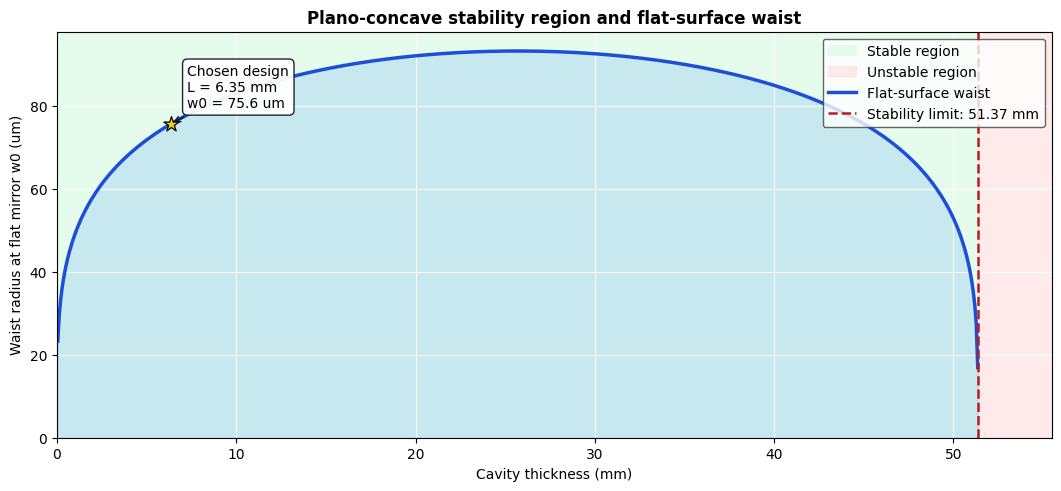

In [26]:
import matplotlib.pyplot as plt

# Plano-concave stability condition with the optical-length convention:
#     0 < n * L_physical < ROC
# The waist is located at the flat mirror and does not depend on reflectivity.
stability_limit_mm = 10.0 * roc_cm / n
thickness_scan_mm = np.linspace(0.05, 1.08 * stability_limit_mm, 700)
stable = n * thickness_scan_mm / 10.0 < roc_cm

z_R_eff_scan_cm = rayleigh_length_plano_concave_cm(thickness_scan_mm, roc_cm, n)
z_R_inside_scan_m = z_R_eff_scan_cm / n * 1e-2
waist_flat_um = np.sqrt(lambda0_m * z_R_inside_scan_m / (np.pi * n)) * 1e6
waist_flat_um[~stable] = np.nan

chosen_stable = n * L_choice_mm / 10.0 < roc_cm
chosen_z_R_inside_m = rayleigh_length_plano_concave_cm(L_choice_mm, roc_cm, n) / n * 1e-2
chosen_waist_um = np.sqrt(lambda0_m * chosen_z_R_inside_m / (np.pi * n)) * 1e6

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
fig.patch.set_facecolor("white")

ax.axvspan(0, stability_limit_mm, color="#dcfce7", alpha=0.72, label="Stable region")
ax.axvspan(stability_limit_mm, thickness_scan_mm.max(), color="#fee2e2", alpha=0.72, label="Unstable region")
ax.plot(thickness_scan_mm, waist_flat_um, color="#1d4ed8", linewidth=2.5, label="Flat-surface waist")
ax.fill_between(thickness_scan_mm, 0, waist_flat_um, color="#60a5fa", alpha=0.22)
ax.axvline(stability_limit_mm, color="#b91c1c", linestyle="--", linewidth=1.8, label=f"Stability limit: {stability_limit_mm:.2f} mm")

if chosen_stable:
    ax.scatter(L_choice_mm, chosen_waist_um, s=130, marker="*", facecolor="#facc15", edgecolor="black", linewidth=0.9, zorder=6)
    ax.annotate(
        f"Chosen design\nL = {L_choice_mm:.2f} mm\nw0 = {chosen_waist_um:.1f} um",
        xy=(L_choice_mm, chosen_waist_um),
        xytext=(12, 12),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color="#111827", linewidth=1.1),
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#111827", alpha=0.94),
    )

ax.set_title("Plano-concave stability region and flat-surface waist", fontweight="bold")
ax.set_xlabel("Cavity thickness (mm)")
ax.set_ylabel("Waist radius at flat mirror w0 (um)")
ax.set_xlim(0, thickness_scan_mm.max())
ax.set_ylim(bottom=0)
ax.grid(True, color="white", linewidth=0.8, alpha=0.9)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="0.25")

plt.show()